In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from rich import print

import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [2]:
forcing_path_ERA5 = Path.home() / "BEP-beau/BEP/code" / "CatchmentArea" / "ERA5_3" / "own_shapefile_3"
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"  
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)
data = pd.read_csv("mohembo_daily_water_discharge_data.csv", index_col='date', parse_dates=True, dayfirst=True)
data = data.resample('D').interpolate()
data.columns = ['Observed discharge (m^3/s)']
data = data[~data.index.year.isin([1974, 2021])]

In [3]:
Area_km2 = 173696.852

def mmday_to_m3s(Q_sim_mmday, area_km2):
    return (Q_sim_mmday * area_km2) / 86.4

In [4]:
print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='1970-01-01T00:00:00Z',
    end_time='2020-12-31T00:00:00Z',
    directory=PosixPath('/home/beau/BEP-beau/BEP/code/CatchmentArea/ERA5_3/own_shapefile_3/work/diagnostic/script')
,
    shape=PosixPath('/home/beau/BEP-beau/BEP/code/CatchmentArea/ERA5_3/own_shapefile_3/work/diagnostic/script/Catch
mentArea_4326.shp'),
    filenames={
        'pr': 'OBS6_ERA5_reanaly_1_day_pr_1970-2020.nc',
        'tas': 'OBS6_ERA5_reanaly_1_day_tas_1970-2020.nc',
        'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_1970-2020.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

In [5]:
par_0 = [1.46021786e+00, 3.48870515e-01, 6.88560472e+02, 3.82660027e+00,
       2.89658094e-01, 2.60605631e+00, 1.55160449e-02, 8.45162498e-03,
       8.95249330e-01]

param_names = ["Imax",
               "Ce",
               "Sumax",
               "Beta",
               "Pmax",
               "Tlag",
               "Kf",
               "Ks",
               "FM"
               ]

print(list(zip(param_names, par_0)))

[
    ('Imax', 1.46021786),
    ('Ce', 0.348870515),
    ('Sumax', 688.560472),
    ('Beta', 3.82660027),
    ('Pmax', 0.289658094),
    ('Tlag', 2.60605631),
    ('Kf', 0.0155160449),
    ('Ks', 0.00845162498),
    ('FM', 0.89524933)
]

In [6]:
s_0 = np.array([0,  100,  0,  5,  0])

In [7]:
model = ewatercycle.models.HBV(forcing=ERA5_forcing)

In [8]:
config_file, _ = model.setup(parameters=par_0, initial_storage=s_0)

In [9]:
model.initialize(config_file)

In [10]:
Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

In [11]:
model.finalize()

In [12]:
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

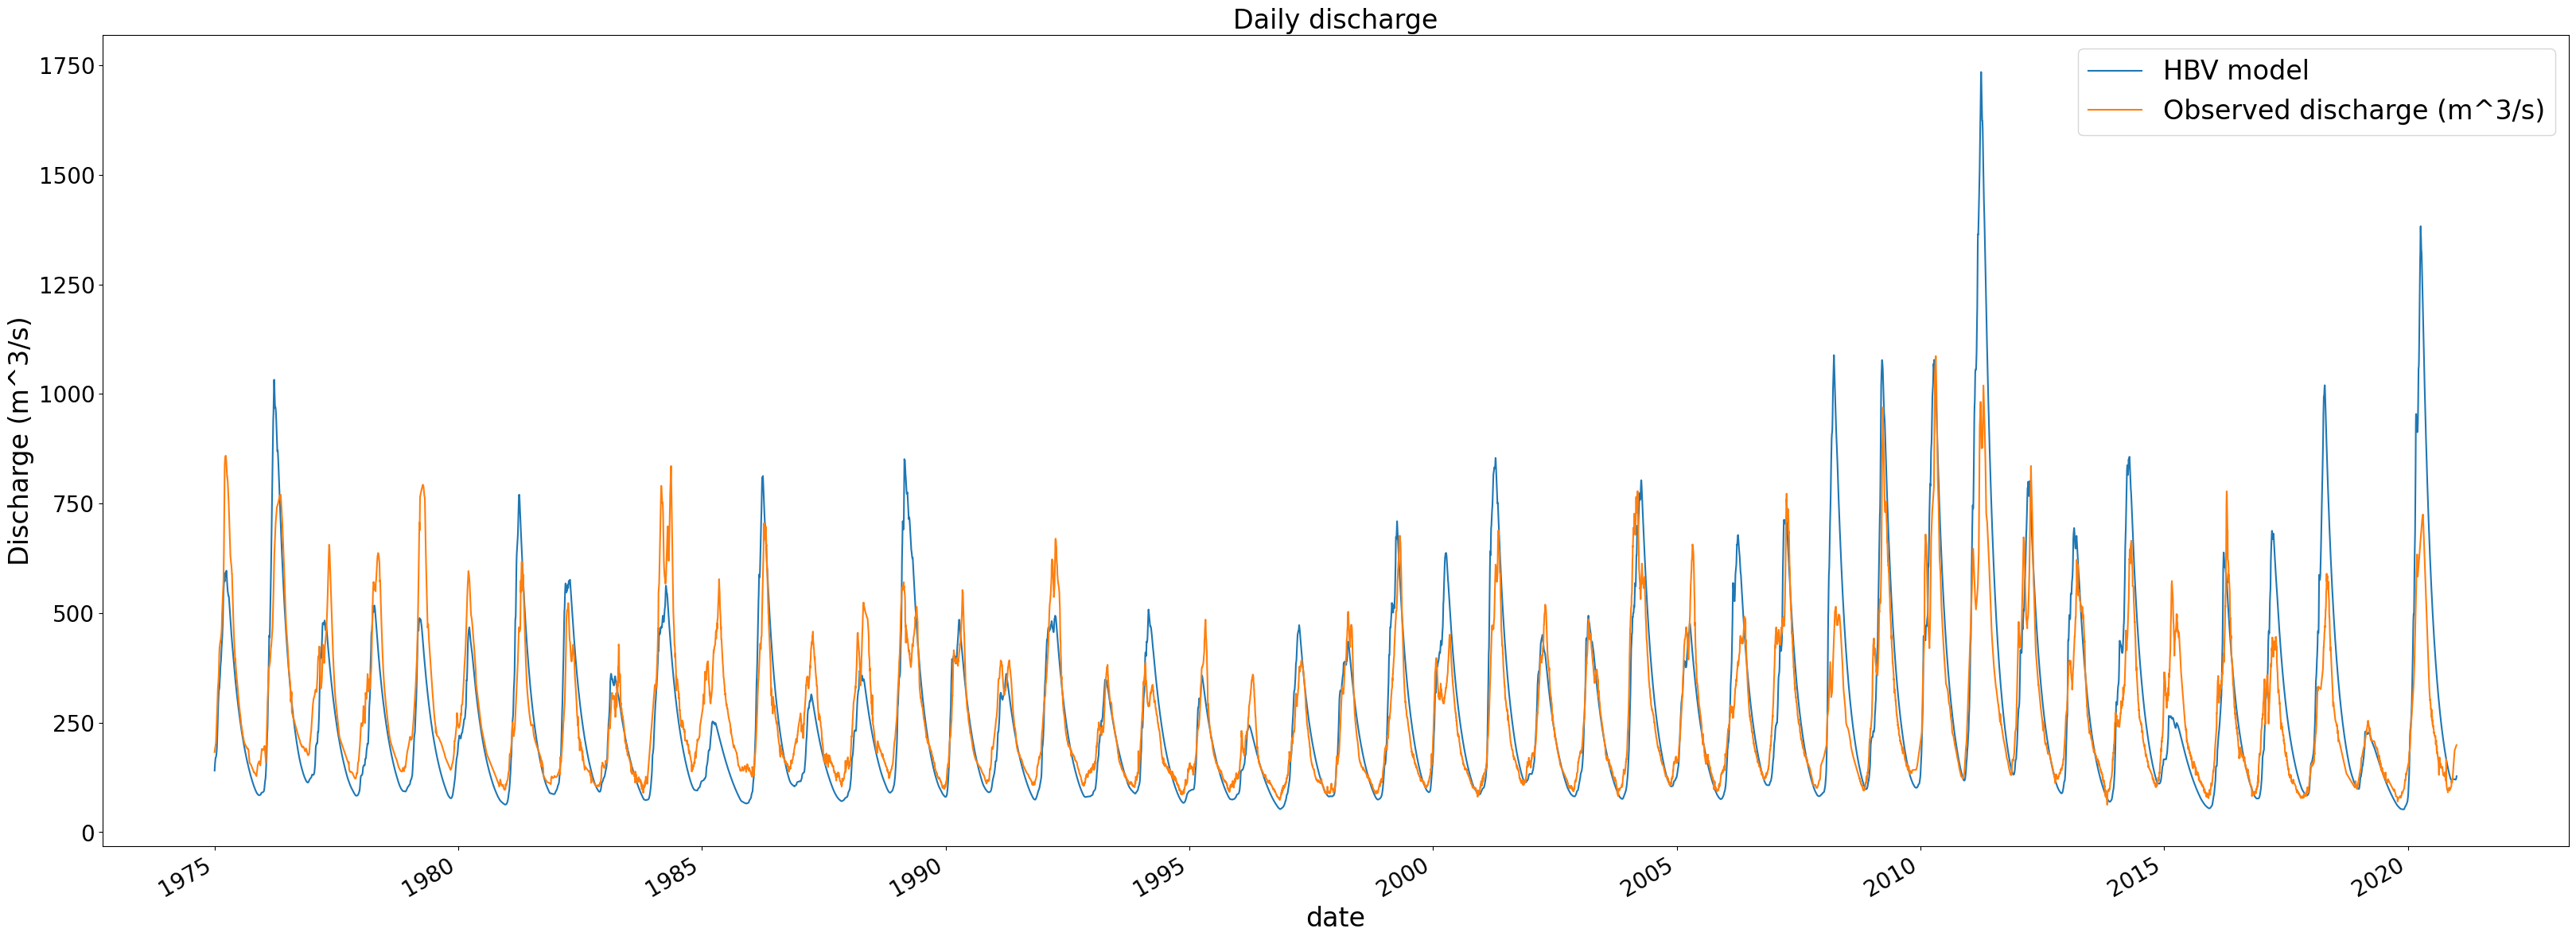

In [13]:
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")

fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
Q_model_pd['1975'::].plot(ax=ax)
data.plot(ax=ax)
plt.legend(fontsize=24)
plt.title('Daily discharge', fontsize=24)
plt.ylabel("Discharge (m^3/s)");

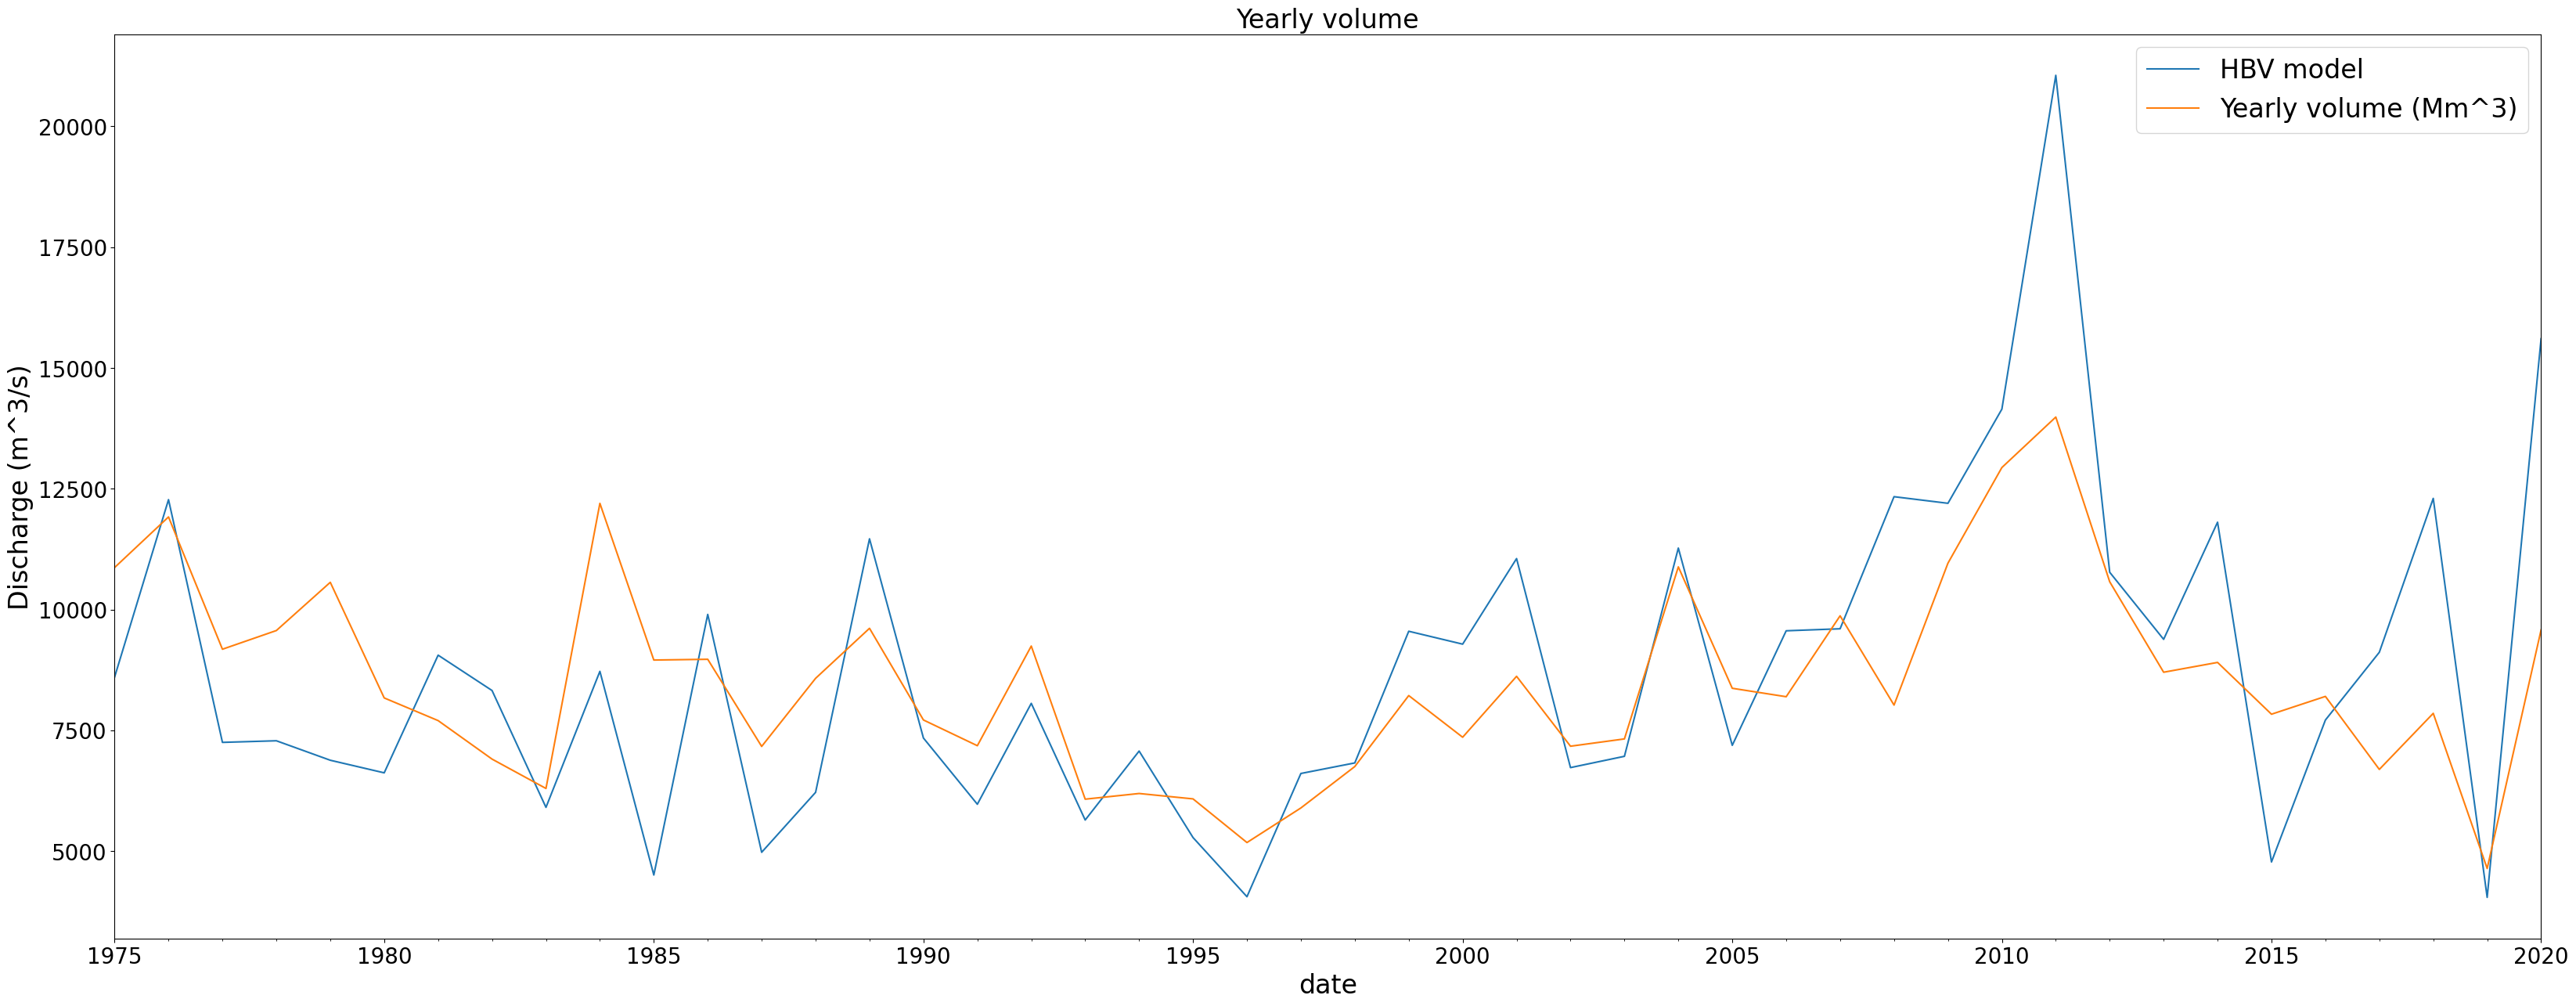

In [21]:
Q_model_pd_volume = (Q_model_pd * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume = (data * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.columns = ['Yearly volume (Mm^3)']

fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
Q_model_pd_volume['1975'::].plot(ax=ax)
yearly_volume.plot(ax=ax)
plt.legend(fontsize=24)
plt.title('Yearly volume', fontsize=24)
plt.ylabel("Discharge (m^3/s)");

In [16]:
Q_model_pd_volume = Q_model_pd_volume[~Q_model_pd_volume.index.year.isin([1970, 1971, 1972, 1973, 1974])]
print(Q_model_pd_volume.mean())
Q_model_pd_volume.sort_values().head(10)

8722.193505686817

2019-12-31    4041.268385
1996-12-31    4054.460941
1985-12-31    4503.574939
2015-12-31    4773.797822
1987-12-31    4974.131402
1995-12-31    5278.818361
1993-12-31    5642.233003
1983-12-31    5903.935187
1991-12-31    5968.349658
1988-12-31    6214.177778
Name: HBV model, dtype: float64